In [1]:
"""
Initial imports and function declarations
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)

import ufl

def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q)
    w = fd.TestFunction(z.function_space())
    return fd.replace(q, {z: w})


# redundant, use the imports instead
n = 3 #Constant(glen_flow_law)
m = 3 #Constant(weertman_sliding_law)

# fields are mutable state?
# parameters are immutable?
# This uses the global variable s, which is mutable. Should it be part of fields?
def friction_law(**kwargs):
    τ, u, h = map(kwargs.get, ("basal_stress", "velocity", "thickness"))

    parameters = ("sliding_coefficient", "sliding_exponent")
    K, m = map(kwargs.get, parameters)

    p_W = lag(ρ_W * g * max_value(0, -(s - h)))
    p_I = ρ_I * g * h
    r = Constant(0.99)
    ϕ = lag(conditional(p_W > r * p_I, 0, 1))

    σ = get_test_function(τ)
    τ_2 = inner(τ, τ)

    if m == 1:
        τ_m = Constant(1.0)
    elif m == 3:
        τ_m = τ_2
    elif m == 5:
        τ_m = τ_2 ** 2
    else:
        raise ValueError("Sliding law exponent must be in [1, 3, 5]!")

    f = ϕ if m == 1 else ϕ ** m
    return inner(K * τ_m * τ + f * u, σ) * dx


def flow_law(**kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = mesh.geometric_dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u))
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx


def momentum_balance(**kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS

    return cell_balance + facet_balance


def terminus(**kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)


def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2



def mass_balance(**kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
"""
Initialization of the bed geometry and velocity/height profiles
"""

lx = 610e3
nx = 450

mesh = fd.IntervalMesh(nx, lx, name="mesh")
thickness_element = fd.FiniteElement("DG", "interval", 0)
bed_element = fd.FiniteElement("CG", "interval", 1)
degree = 1

velocity_element = fd.FiniteElement("CG", "interval", degree)
stress_element = fd.FiniteElement("DG", "interval", degree - 1)

Q = fd.FunctionSpace(mesh, thickness_element)
S = fd.FunctionSpace(mesh, bed_element)
V = fd.VectorFunctionSpace(mesh, velocity_element)
Σ = fd.TensorFunctionSpace(mesh, stress_element, symmetry=True)

Lx = Constant(lx)

In [3]:
"""
We utilize the mismip+ bed
"""
    
B_0 = Constant(-150)
B_2 = Constant(-728.8)
B_4 = Constant(343.91)
B_6 = Constant(-50.57)
x_c = Constant(300e3)


def mismip_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    X = x / x_c
    B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6
    z_deep = Constant(-720)    
    return B_x

# currently unused
def linear_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    b_in, b_out = 200, -400
    b_x = (b_in - (b_in - b_out) * x / Lx)
    return b_x

In [4]:
x = fd.SpatialCoordinate(mesh)[0]

b = fd.Function(S).interpolate(mismip_bed(mesh))

h_in = Constant(200.0)
δh = Constant(100.0)
h_expr = h_in - δh * x / Lx
h_0 = fd.Function(Q).interpolate(h_expr)
h = h_0.copy(deepcopy=True)

ϵ = Constant(0.1)
s_expr = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s0 = fd.Function(Q).interpolate(s_expr)
z_b = fd.Function(Q).interpolate(s0 - h)

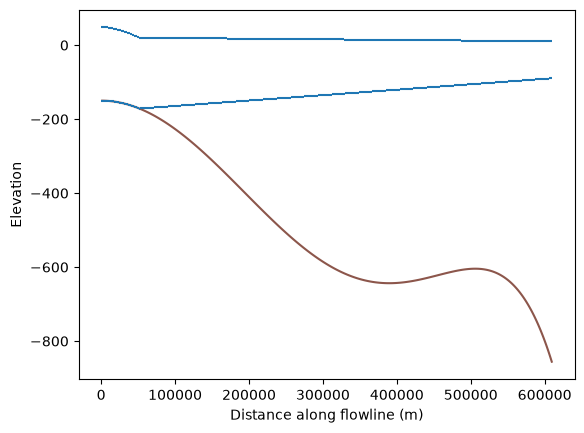

In [5]:
fig, axes = plt.subplots()
fd.plot(b, axes=axes, edgecolor="tab:brown")
fd.plot(s0, axes=axes, edgecolor="tab:blue")
fd.plot(z_b, axes=axes, edgecolor="tab:blue")
axes.set_xlabel('Distance along flowline (m)')
axes.set_ylabel('Elevation')
plt.show()

In [6]:
δu = fd.Constant(90.0)
expr = fd.as_vector([δu * x / Lx])  # 1-component vector
u_0 = fd.Function(V).interpolate(expr)

In [7]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** n)
u_c = Constant(K * τ_c ** m)

In [8]:
print(f"Strain rate: {1000 * float(ε_c):0.3f} m / yr / km")
print(f"Speed:       {float(u_c):0.3f} m / yr")
print(f"at stress of {1000 * float(τ_c):0.3f} kPa")

Strain rate: 0.020 m / yr / km
Speed:       1.000 m / yr
at stress of 10.000 kPa


In [9]:
"""
Initialization of function spaces and mass/momentum balance
"""

Z = V * Σ * V
z = fd.Function(Z)
z.sub(0).assign(u_0);

inflow_ids = (1,)
terminus_ids = (2,)

#s = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s = max_value(b + h, (1 - ρ_I / ρ_W) * h)

u, M, τ = fd.split(z)

# Mutable State (partially derived from z?)?
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

parameters_1 = {
    "flow_law_coefficient": ε_c / τ_c,
    "flow_law_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
    "sliding_exponent": 1,
}

parameters_3 = {
    "flow_law_coefficient": ε_c / τ_c ** n,
    "flow_law_exponent": n,
    "sliding_coefficient": u_c / τ_c ** m,
    "sliding_exponent": m,
}

α = Constant(1e-3)
F_flow_law_1 = flow_law(**fields, **parameters_1)
F_flow_law_3 = flow_law(**fields, **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**fields, **parameters_1)
F_sliding_law_3 = friction_law(**fields, **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F = F_flow_law + F_sliding_law + F_balance + F_terminus

inflow_bc = fd.DirichletBC(Z.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

fparams = {"quadrature_degree": 8}
pparams = {"bcs": bcs, "form_compiler_parameters": fparams}
problem = fd.NonlinearVariationalProblem(F, z, **pparams)

logfile = ":mismipp-dual.log"
sparams = {
    "solver_parameters": {
        "snes_max_it": 200,
        "snes_linesearch_type": "nleqerr",
        "snes_monitor": logfile,
        "pc_factor_mat_solver_type": "umfpack",
    }
}
solver = fd.NonlinearVariationalSolver(problem, **sparams)
solver.solve()
u, M, τ = z.subfunctions

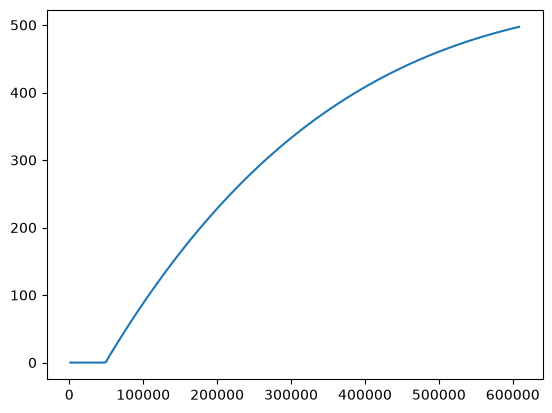

In [10]:
fig, axes = plt.subplots()
fd.plot(fd.Function(S).interpolate(u[0]), axes=axes);

In [11]:
W = V * Σ * V * Q

w = fd.Function(W)
w.sub(0).assign(z.sub(0))
w.sub(1).assign(z.sub(1))
w.sub(2).assign(z.sub(2))
w.sub(3).assign(h);

In [12]:
inflow_bc = fd.DirichletBC(W.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

u, M, τ, h = fd.split(w)
v, N, σ, η = fd.TestFunctions(W)

s = lag(max_value(b + h, (1 - ρ_I / ρ_W) * h))
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

h_min = Constant(1e-3)
regularized = {"thickness": max_value(h_min, h)}

H = Constant(500.0)

F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F_momentum = F_flow_law + F_sliding_law + F_balance + F_terminus

In [13]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**(fields | regularized))
F_terminus = terminus(**(fields | regularized), terminus_ids=terminus_ids)

F_momentum_regularized = F_flow_law + F_sliding_law + F_balance + F_terminus

In [14]:
a_0 = Constant(1.0)
m_0 = Constant(1.125)
z_b = s - h
heaviside = lambda z: 1 / (1 + fd.exp(-z))
#a_expr = a_0 - m_0 * heaviside(-z_b) * heaviside(z_b - b)
a_expr = a_0 - m_0 * heaviside(z_b - b)

In [15]:
F_mass = mass_balance(
    thickness=h, velocity=u, accumulation=lag(a_expr), thickness_in=h_0
)
F = F_momentum + F_mass
Fp = F_momentum_regularized + F_mass

In [16]:
"""
Main driver:
"""

method = irksome.BackwardEuler()
t = Constant(0.0)
timestep = 0.2
dt = Constant(timestep)

fparams = {"quadrature_degree": 8}
sparams = {
    "snes_monitor": ":mismip-dual-ts.log",
    "snes_type": "vinewtonrsls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_max_it": 40,
    "snes_atol": 2e-8,
    "pc_factor_mat_solver_type": "mumps",
}
lower = fd.Function(W)
upper = fd.Function(W)
lower.assign(-np.inf)
lower.sub(3).assign(0.0)
upper.assign(+np.inf)

params = {
    "bcs": bcs,
    "form_compiler_parameters": fparams,
    "solver_parameters": sparams,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": ("stage", lower, upper)
}

solver = irksome.TimeStepper(F, method, t, dt, w, **params, Jp=Fp)

In [17]:
ws = [w.copy(deepcopy=True)]
final_time = 3000.0
num_steps = int(final_time / timestep)

for step in trange(num_steps):
    solver.advance()
    ws.append(w.copy(deepcopy=True))

  0%|          | 0/15000 [00:00<?, ?it/s]

In [18]:
u, M, τ, h = w.subfunctions

In [19]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h))
z_b = fd.Function(Q).interpolate(s - h)

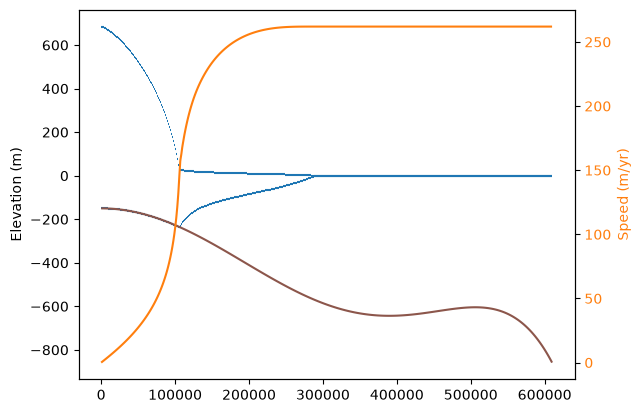

In [20]:
fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

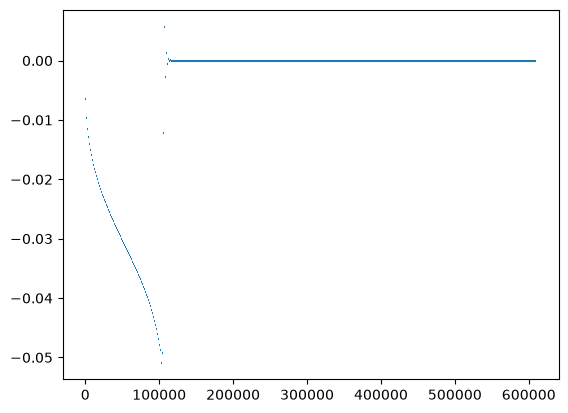

In [21]:
τ_b = fd.Function(Q).project(τ[0])
fig, ax = plt.subplots()
fd.plot(τ_b, axes=ax);

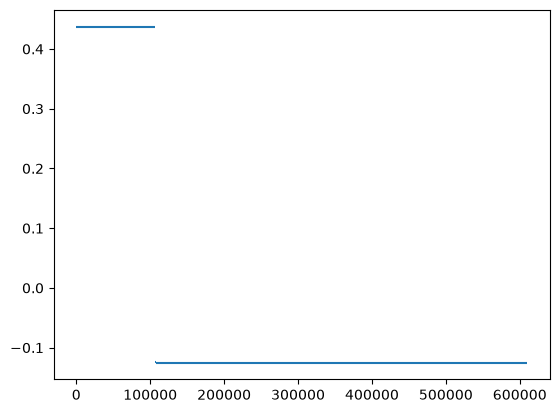

In [22]:
fig, ax = plt.subplots()
a_expr = a_0 - m_0 * heaviside(z_b - b)
a = fd.Function(Q).project(a_expr)
fd.plot(a, axes=ax);

In [23]:
# # create a function on our mesh that will assign each element in our mesh a number
# V_dg = FunctionSpace(mesh, "DG", 0)
# cell_marker = Function(V_dg)

# marker_array = cell_marker.dat.data

# for i in range(415):
#     marker_array[target_cell_index] = target_

In [24]:
def create_submesh(k):
    # create a function on our mesh that will assign each element in our mesh a number
    V_dg = fd.FunctionSpace(mesh, "DG", 0)
    cell_marker = fd.Function(V_dg)

    marker_array = cell_marker.dat.data
    marker_array[k] = 1
    relabeled_mesh = fd.RelabeledMesh(mesh, [cell_marker], [k])
    return fd.mesh.Submesh(relabeled_mesh, 1, k) 

In [25]:
element_length = 610_000/450

In [26]:
print(create_submesh(3).topological_dimension)

1


In [27]:
# def end_of_glacier(f):
#     """
#     This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
#     """
#     f_values = f.dat.data_ro
#     zero_nodes = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]

#     # if the this is the case then the terminus lies outside of our domain
#     if len(zero_nodes) == 0:
#         return 'empty'

#     # this gives us the first node of our mesh at which the thickness is zero
#     initial_guess = zero_nodes[0]

#     # we create a submesh with just the element that contains our terminus
#     submesh = create_submesh(initial_guess-1) 

#     print(initial_guess)
#     print(submesh.coordinates.dat.data_ro)

#     points = np.arange((initial_guess-1)*element_length, (initial_guess)*element_length)[:, None]
#     # print(points)
#     vom = fd.VertexOnlyMesh(submesh, points)
#     P = fd.FunctionSpace(vom, "DG", 0)

#     # "DG", "interval", 0
#     V_sub = fd.FunctionSpace(submesh, "DG", 0)
#     f_submesh = fd.Function(V_sub).project(f)

#     f_at_points = fd.assemble(fd.interpolate(f_submesh, P)) 
#     f_values = f_at_points.dat.data_ro

#     print(f_values)

#     zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
#     print(zeros)
#     return int(initial_guess*element_length + zeros[0])

In [28]:
215*element_length

291444.44444444444

In [29]:
print(end_of_glacier(h))

NameError: name 'end_of_glacier' is not defined

In [ ]:
def end_of_glacier_slow(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, 1)[:, None] # list of lists (requirement for the vertex only mesh)
    vom = fd.VertexOnlyMesh(f_mesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    # if f_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
    #     return 'empty'
    zeros = np.where(f_values==0)[0]

    return int(zeros[0])*1 # this gives us the first point at which the thickness is zero

In [ ]:
print(end_of_glacier_slow(h))

291445
